# TODO
- deep known about dataset
- feature engineering
- model building

### Import

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### Suppress warnings
Configure the warnings module to ignore non‑critical warnings.

In [2]:
import warnings

warnings.filterwarnings("ignore")

### Pull dataset and anomalies from database

In [12]:
df = pd.read_csv("onlinefraud.csv")
df = df.drop(columns= "isFlaggedFraud")

df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0


## Exploratory Data Analysis (EDA)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            str    
 2   amount          float64
 3   nameOrig        str    
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        str    
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
dtypes: float64(5), int64(2), str(3)
memory usage: 657.7 MB


In [39]:
df.shape

(6362620, 10)

In [40]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
dtype: int64

- The dataset contains no missing values

In [41]:
df.duplicated().sum()

np.int64(0)

- No duplicate transactions were found in the dataset.

In [4]:
# Use smaller dtype for numberical columns
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = pd.to_numeric(df[col], downcast= 'float')
    if df[col].dtype == 'int64':
        df[col] = pd.to_numeric(df[col], downcast= 'unsigned')
        
df['type'] = df['type'].astype('category')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 10 columns):
 #   Column          Dtype   
---  ------          -----   
 0   step            uint16  
 1   type            category
 2   amount          float64 
 3   nameOrig        str     
 4   oldbalanceOrg   float64 
 5   newbalanceOrig  float64 
 6   nameDest        str     
 7   oldbalanceDest  float64 
 8   newbalanceDest  float64 
 9   isFraud         uint8   
dtypes: category(1), float64(5), str(2), uint16(1), uint8(1)
memory usage: 491.3 MB


In [43]:
df.describe(include= [np.number]).T

,count,mean,std,min,25%,50%,75%,max
step,6362620.0,2.433972e+02,1.423320e+02,1.0,156.00,239.000,3.350000e+02,7.430000e+02
amount,6362620.0,1.798619e+05,6.038582e+05,0.0,13389.57,74871.940,2.087215e+05,9.244552e+07
oldbalanceOrg,6362620.0,8.338831e+05,2.888243e+06,0.0,0.00,14208.000,1.073152e+05,5.958504e+07
newbalanceOrig,6362620.0,8.551137e+05,2.924049e+06,0.0,0.00,0.000,1.442584e+05,4.958504e+07
oldbalanceDest,6362620.0,1.100702e+06,3.399180e+06,0.0,0.00,132705.665,9.430367e+05,3.560159e+08
newbalanceDest,6362620.0,1.224996e+06,3.674129e+06,0.0,0.00,214661.440,1.111909e+06,3.561793e+08
isFraud,6362620.0,1.290820e-03,3.590480e-02,0.0,0.00,0.000,0.000000e+00,1.000000e+00


In [44]:
df.describe(include= ['str', 'category']).T

,count,unique,top,freq
type,6362620,5,CASH_OUT,2237500
nameOrig,6362620,6353307,C2098525306,3
nameDest,6362620,2722362,C1286084959,113


In [45]:
df['nameOrig'].value_counts()

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
              ..
C786484425     1
C1529008245    1
C1162922333    1
C1685995037    1
C1280323807    1
Name: count, Length: 6353307, dtype: int64

- There are 6,353,307 unique customers initiating transactions.

In [46]:
df['nameDest'].value_counts()

nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
              ... 
C1812552860      1
C1470998563      1
C1850423904      1
C1881841831      1
C2080388513      1
Name: count, Length: 2722362, dtype: int64

- There are 2,722,362 unique transaction recipients.

In [47]:
for i in df.select_dtypes(include= "category").columns:
    print(df[i].value_counts())
    print("***" * 10)

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64
******************************


### Graphs

In [48]:
# Setting
sns.set_style('whitegrid')

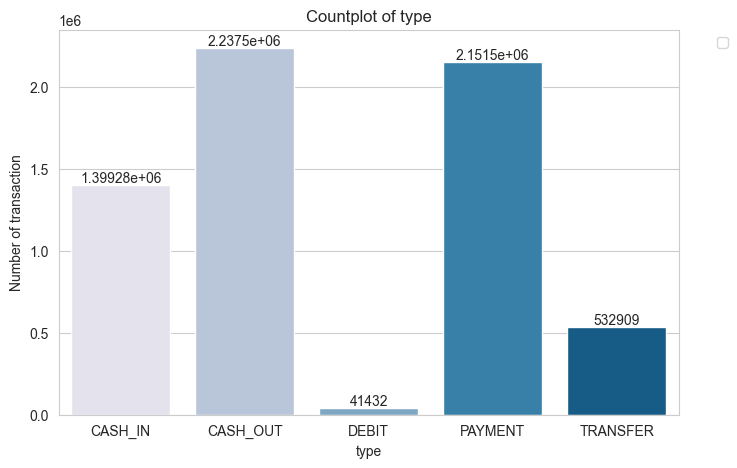

In [49]:
col = 'type'

plt.figure(figsize=(8, 5))

ax = sns.countplot(x=col, data=df, palette= 'PuBu')

for container in ax.containers:
    ax.bar_label(container)

# plt.grid(axis='y', alpha= 0.5)
plt.title(f'Countplot of {col}')
plt.ylabel('Number of transaction')
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.show()

- Cash Out is the most frequent transaction type, followed by Payment, Cash In, Transfer, and Debit.

In [14]:
numberic_cols = df.select_dtypes(include= 'number').columns
numberic_cols

Index(['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest',
       'newbalanceDest', 'isFraud', 'hour_of_day', 'is_Merchant_Dest',
       'errorBalanceOrig', 'errorBalanceDest'],
      dtype='str')

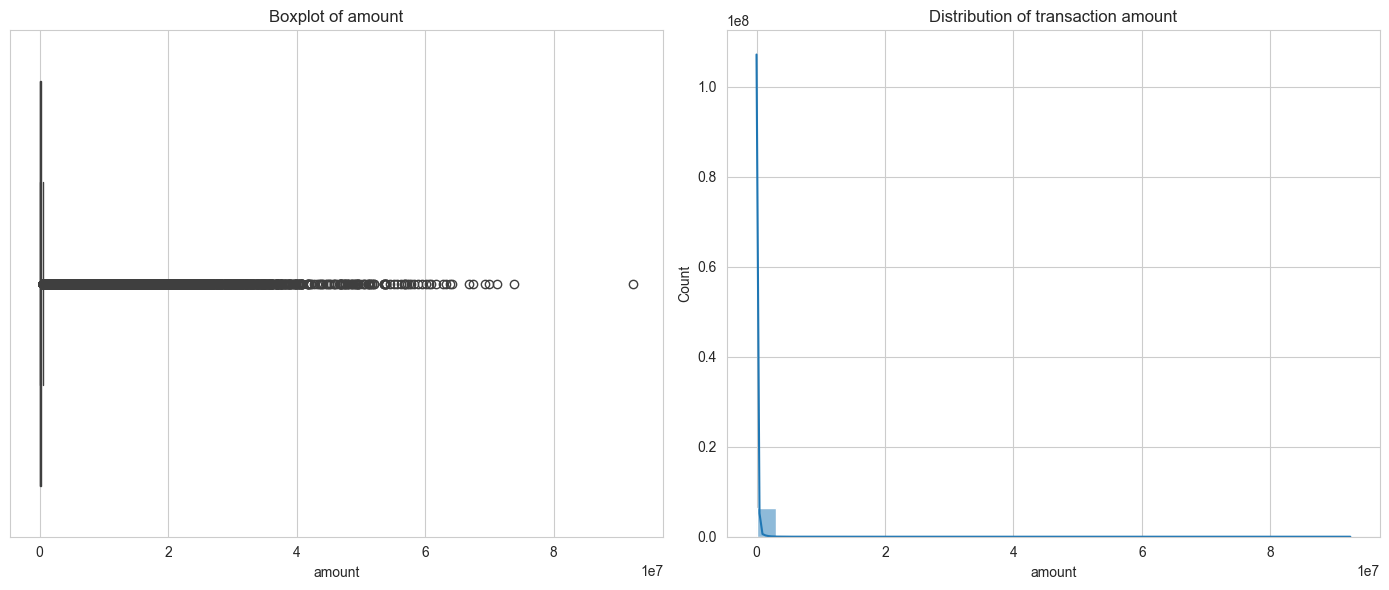

In [51]:
col = 'amount'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- Most transactions occur with relatively low transaction amounts.

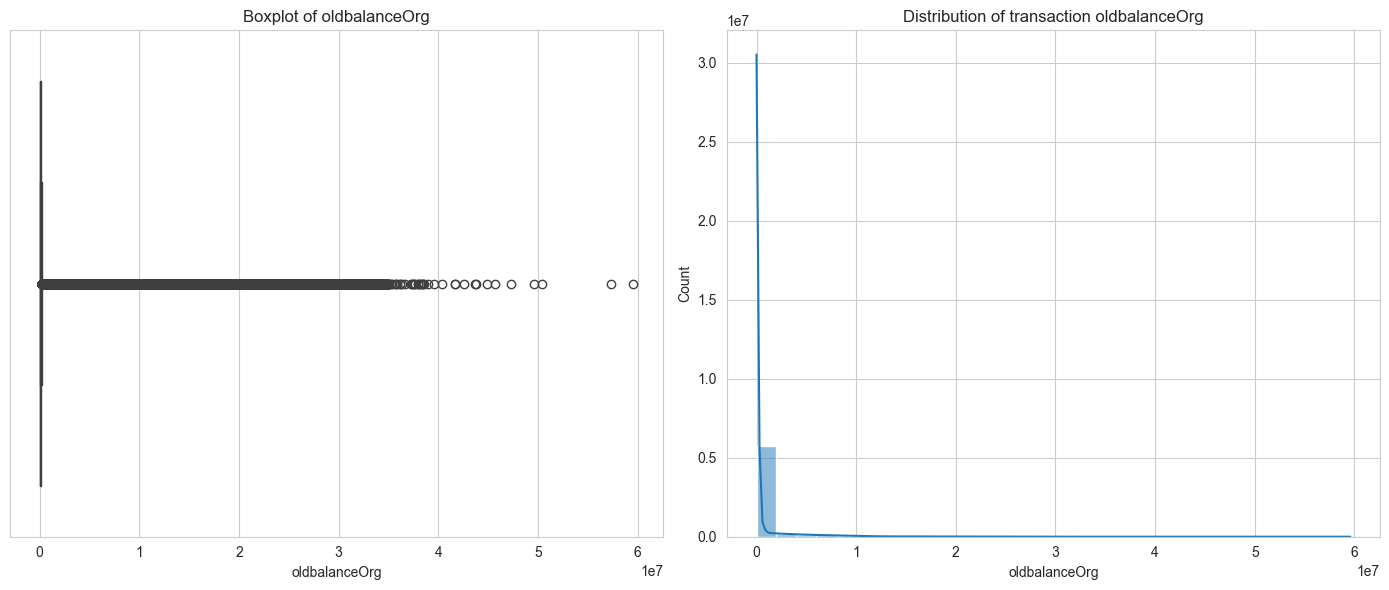

In [52]:
col = 'oldbalanceOrg'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of customer balances before transactions is heavily right-skewed.

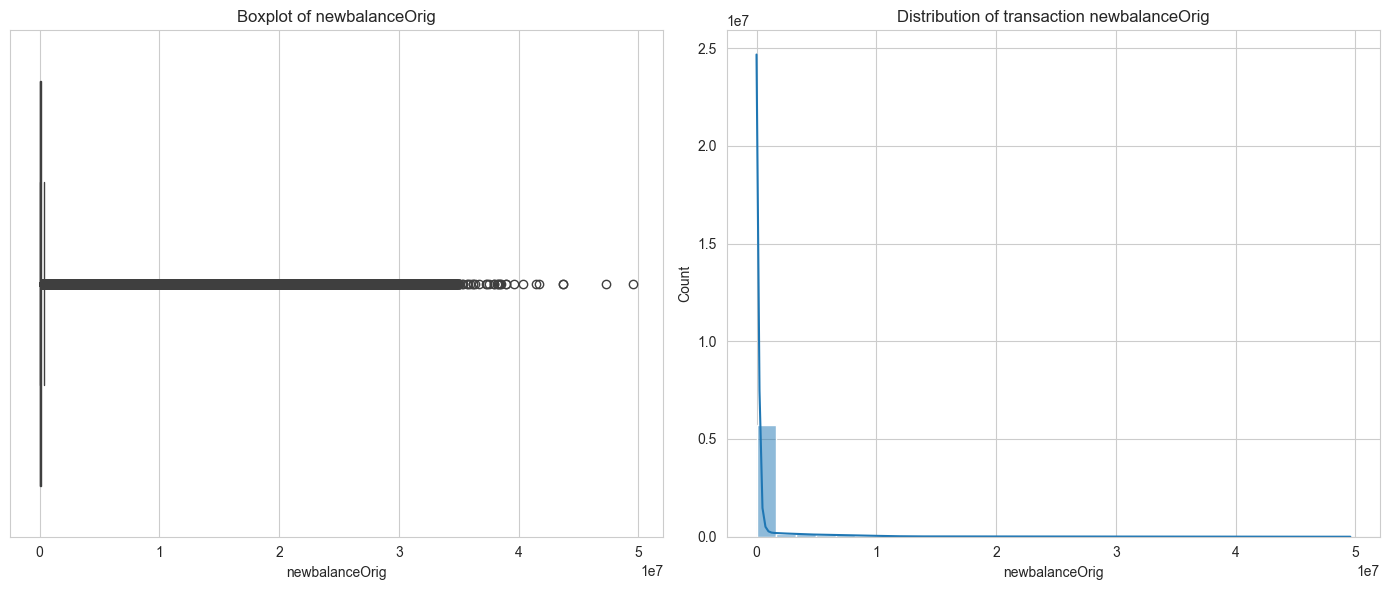

In [53]:
col = 'newbalanceOrig'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of customer balances after transactions is highly right-skewed.

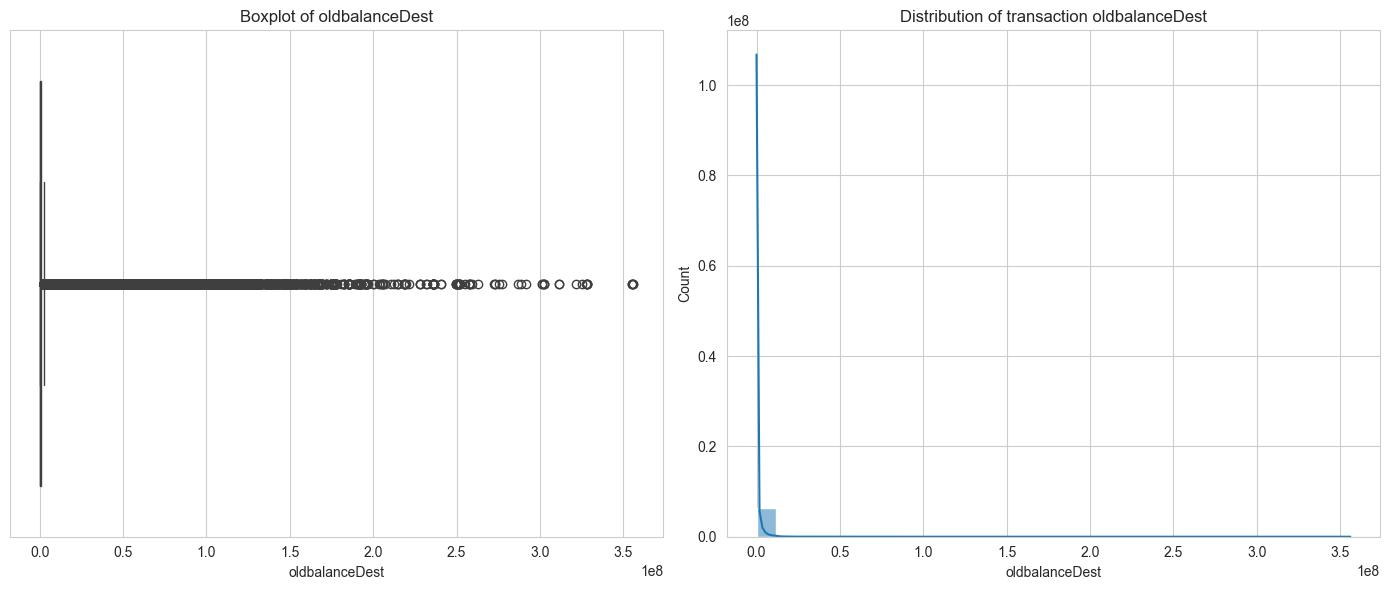

In [54]:
col = 'oldbalanceDest'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of recipient balances before transactions is highly right-skewed.

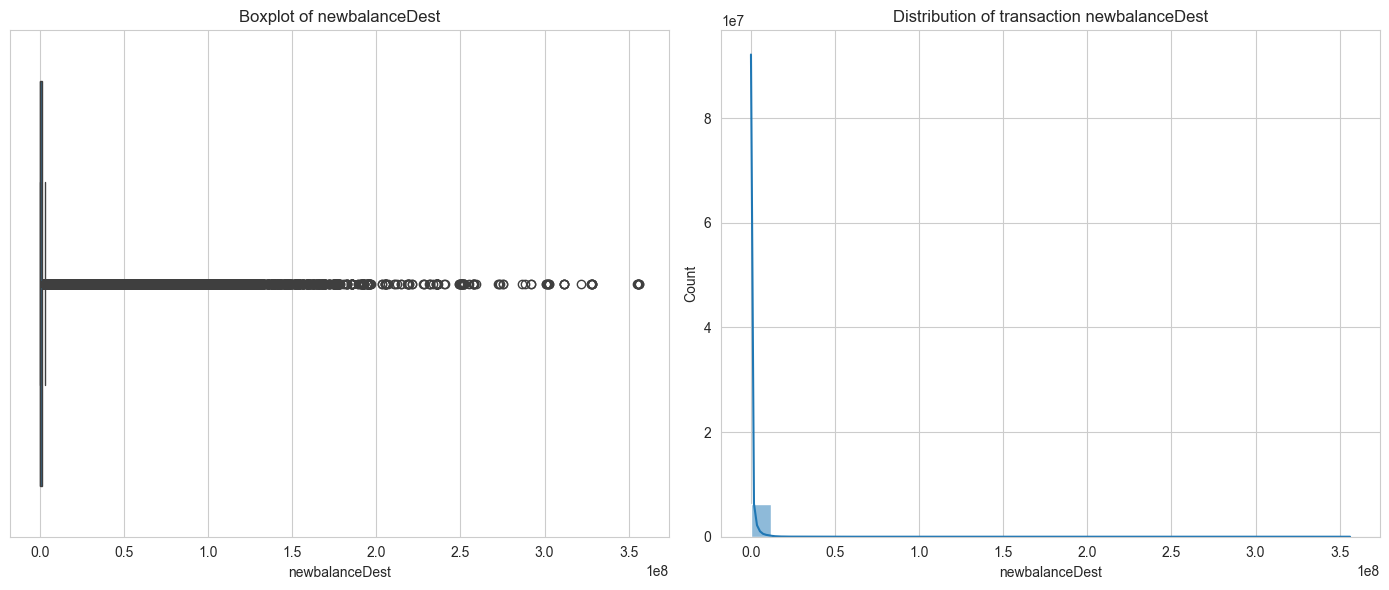

In [55]:
col = 'newbalanceDest'

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Boxplot
sns.boxplot(x=df[col], ax=axes[0])
axes[0].set_title(f'Boxplot of {col}')

# Histogram
sns.histplot(x= df[col], kde=True, bins=30, ax=axes[1])
axes[1].set_title(f'Distribution of transaction {col}')

plt.tight_layout()
plt.show()

- The distribution of recipient balances after transactions is highly right-skewed.

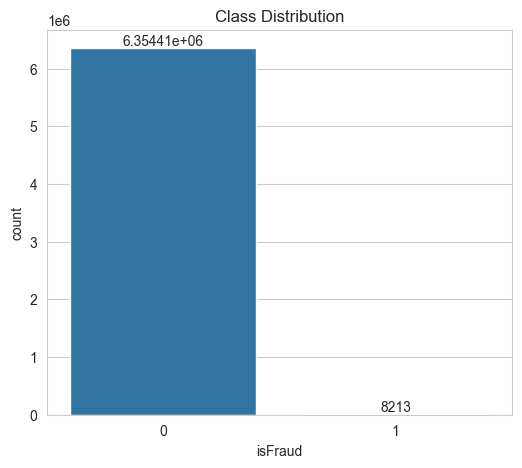

Class counts (0: Non-Fraud, 1: Fraud)
isFraud
0    6354407
1       8213
Name: count, dtype: int64


In [56]:
col = 'isFraud'

plt.figure(figsize=(6, 5))

ax = sns.countplot(x=df[col])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Class Distribution')
plt.show()

print('Class counts (0: Non-Fraud, 1: Fraud)')
print(df[col].value_counts())

- The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.

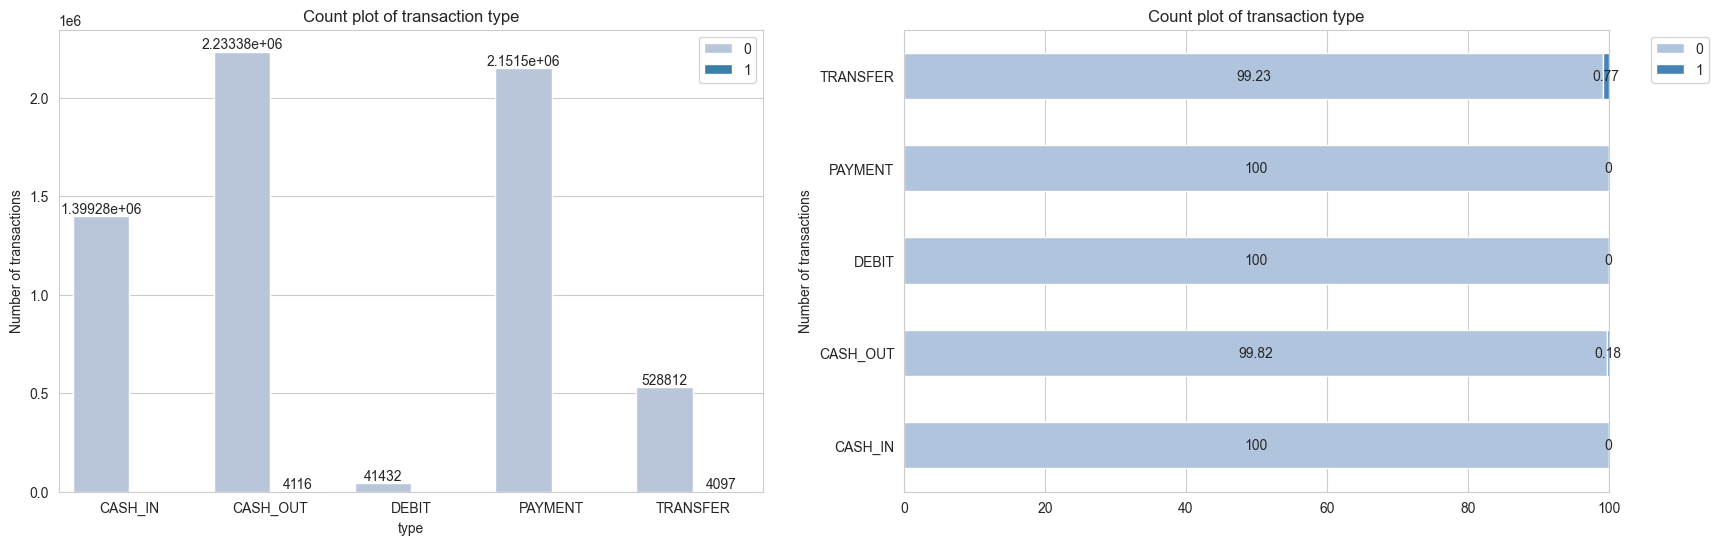

In [57]:
fig, ax = plt.subplots(1,2,figsize=(20,6))

sns.countplot(x='type', data=df, hue='isFraud', palette='PuBu', ax=ax[0])
for container in ax[0].containers:
    ax[0].bar_label(container)
ax[0].set_title('Count plot of transaction type')
ax[0].legend(loc='best')
ax[0].set_ylabel('Number of transactions')

df2 = df.groupby(['type', 'isFraud']).size().unstack(fill_value= 0)
df2.apply(lambda x : round(x/sum(x)*100, 2), axis=1).plot(kind='barh', stacked=True, color=['lightsteelblue', 'steelblue'], ax=ax[1])
for container in ax[1].containers:
    ax[1].bar_label(container, label_type='center')
ax[1].set_title('Count plot of transaction type')
ax[1].legend(bbox_to_anchor=(1.05,1), loc='upper left')
ax[1].set_ylabel('Number of transactions')
ax[1].grid(axis='y')

- Fraudulent transactions occur primarily in Transfer and Cash Out transaction types.

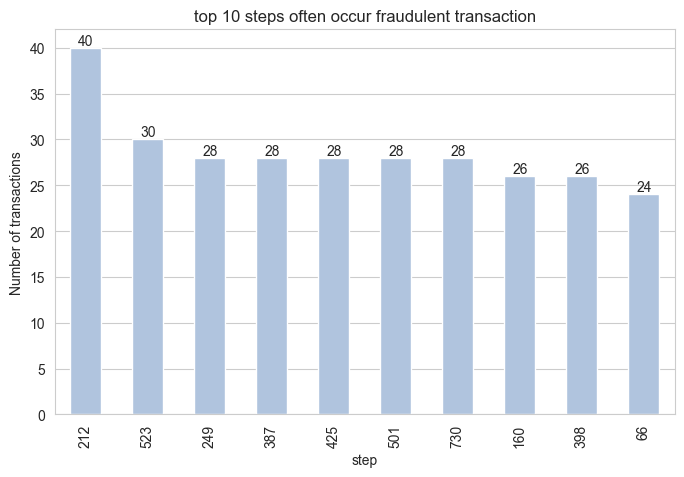

In [58]:
df1 = df[df['isFraud'] == 1]
df2 = df1['step'].value_counts().head(10)

plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 steps often occur fraudulent transaction')
plt.ylabel("Number of transactions")
plt.grid(axis= 'x')
plt.show()

- Step 212 contains the highest number of fraudulent transactions, with 40 recorded cases.

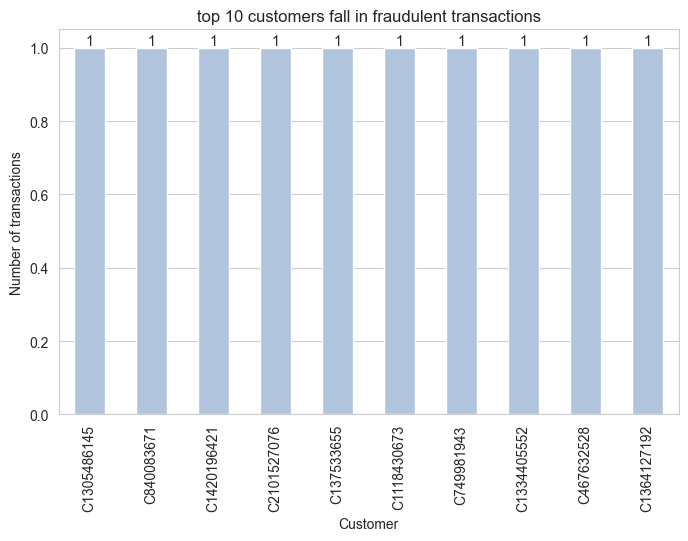

In [59]:
df2 = df1['nameOrig'].value_counts().head(10)
plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 customers fall in fraudulent transactions')
plt.ylabel("Number of transactions")
plt.xlabel("Customer")
plt.grid(axis= 'x')
plt.show()

- Most customers appear in fraudulent transactions only once.

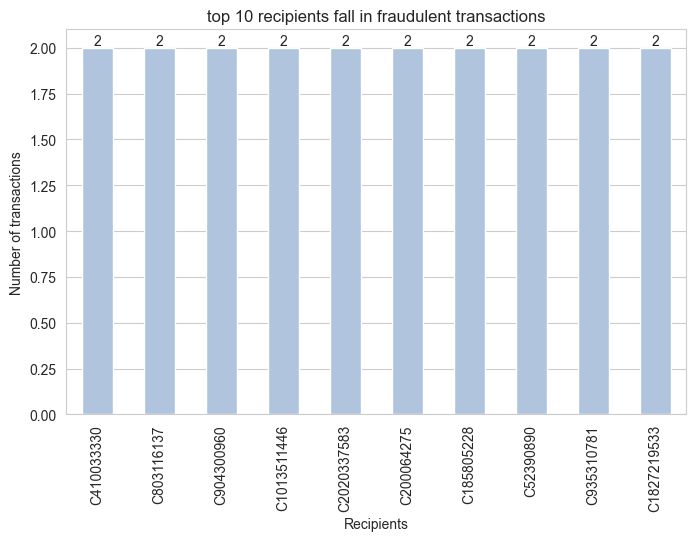

In [60]:
df2 = df1['nameDest'].value_counts().head(10)
plt.figure(figsize= (8,5))
ax = df2.plot(kind= 'bar', color= 'lightsteelblue')

for container in ax.containers:
    ax.bar_label(container)

plt.title('top 10 recipients fall in fraudulent transactions')
plt.xlabel("Recipients")
plt.ylabel("Number of transactions")
plt.grid(axis= 'x')
plt.show()

- Most fraudulent recipients are associated with transactions involving at most two customers.

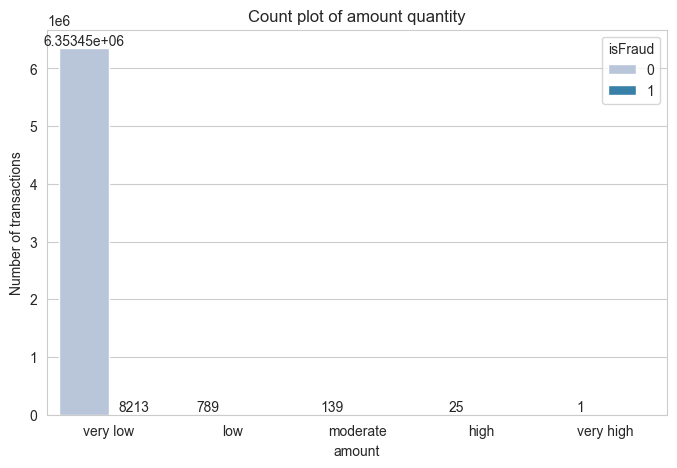

In [61]:
df['quantity'] = pd.cut(df['amount'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'quantity', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of amount quantity')
plt.xlabel('amount')
plt.ylabel('Number of transactions')
plt.show()

- Most fraudulent transactions occur within the very low transaction amount range.

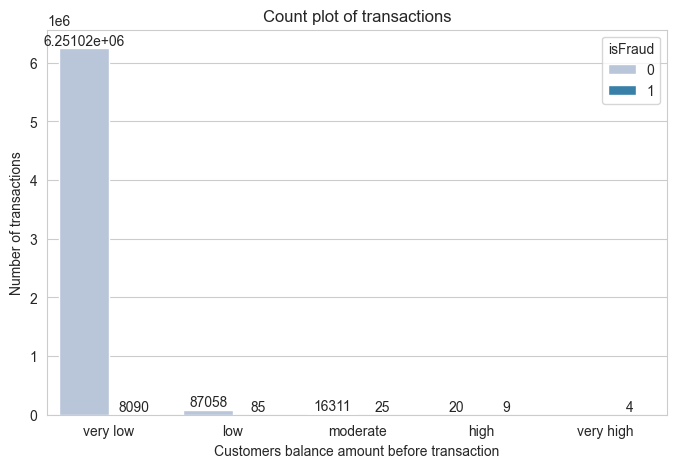

In [62]:
df['oldbalanceOrg_amount'] = pd.cut(df['oldbalanceOrg'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'oldbalanceOrg_amount', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of transactions')
plt.xlabel('Customers balance amount before transaction')
plt.ylabel('Number of transactions')
plt.show()

- Customers with very low account balances are associated with the highest number of fraudulent transactions.

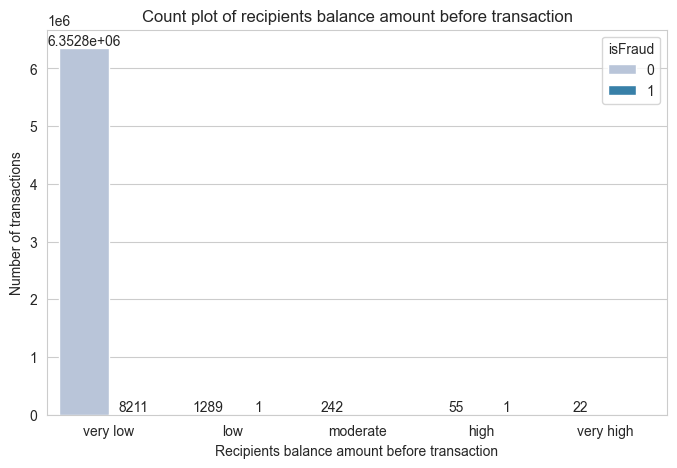

In [63]:
df['oldbalanceDest_amount'] = pd.cut(df['oldbalanceDest'], 5, labels= ['very low', 'low', 'moderate', 'high', 'very high'])

plt.figure(figsize= (8,5))

ax = sns.countplot(data= df, x= 'oldbalanceDest_amount', hue= 'isFraud', palette= 'PuBu')
for container in ax.containers:
    ax.bar_label(container)

plt.title('Count plot of recipients balance amount before transaction')
plt.xlabel('Recipients balance amount before transaction')
plt.ylabel('Number of transactions')
plt.show()

- Most fraudulent recipients have very low account balances.

### Multivariate data visualization

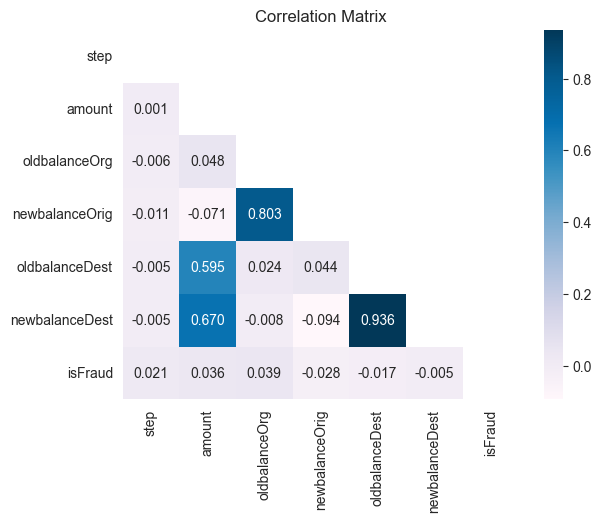

In [64]:
corr = df[numberic_cols].corr('spearman')
sns.heatmap(corr, cbar= True, annot=True, fmt='.3f', cmap= 'PuBu', mask= np.triu(np.ones_like(corr, dtype= bool)))
plt.grid(False)
plt.title('Correlation Matrix')
plt.show()

- oldbalanceOrg and newbalanceOrig show a **strong positive** correlation.
- newbalanceDest and oldbalanceDest exhibit a **strong positive** correlation.
- amount has a **moderate positive** correlation with oldbalanceDest and newbalanceDest.
- amount has a **weak positive** correlation with oldbalanceOrg.

In [13]:
df['hour_of_day'] = df['step'] % 24

df['is_Merchant_Dest'] = df['nameDest'].str.startswith('M').astype(int)

df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']

df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df.loc[df['is_Merchant_Dest'] == 1, 'errorBalanceDest'] = 0

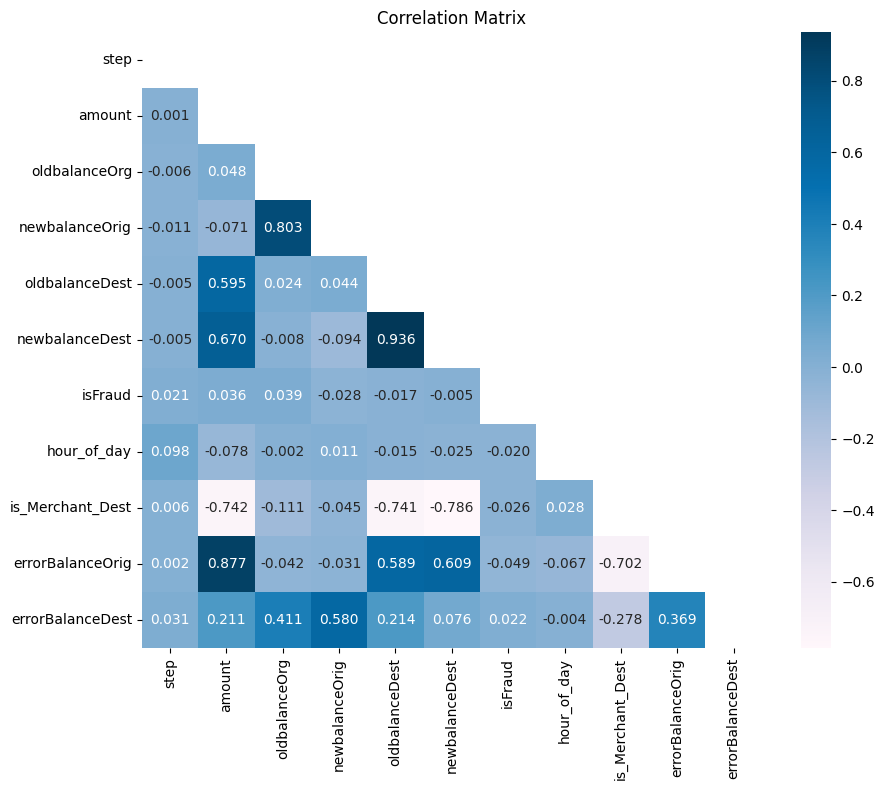

In [19]:
corr = df[numberic_cols].corr('spearman')
plt.figure(figsize= (10, 8))
sns.heatmap(corr, cbar= True, annot=True, fmt='.3f', cmap= 'PuBu', mask= np.triu(np.ones_like(corr, dtype= bool)))
plt.grid(False)
plt.title('Correlation Matrix')
plt.show()

## Preprocessing

In [20]:
# df.drop(['quantity', 'oldbalanceOrg_amount', 'oldbalanceDest_amount'], axis=1, inplace=True)
df = pd.get_dummies(data= df, columns=['type'], dtype= 'int', drop_first= True)
df.head()

,step,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,hour_of_day,is_Merchant_Dest,errorBalanceOrig,errorBalanceDest,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,1,1,0.0,0.0,0,0,1,0
1,1,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,1,1,0.0,0.0,0,0,1,0
2,1,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,1,0,0.0,181.0,0,0,0,1
3,1,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,1,0,0.0,21363.0,1,0,0,0
4,1,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,1,1,0.0,0.0,0,0,1,0


In [37]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.under_sampling import RandomUnderSampler
from imblearn.over_sampling import SMOTE

X = df.drop(['nameOrig', 'nameDest'], axis= 1)
y = X.pop('isFraud')

# Split data
x_train, x_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)

# Apply undersampling ONLY on training data
rus = RandomUnderSampler(random_state=42)

x_train_resampled, y_train_resampled = rus.fit_resample(
    x_train,
    y_train
)

# Apply SMOTE ONLY on training data
# smote = SMOTE(random_state=42)

# x_train_resampled, y_train_resampled = smote.fit_resample(
#     x_train,
#     y_train
# )

In [38]:
# Keep only 1 million rows
# Sample for model comparison
X_sample, _, y_sample, _ = train_test_split(
    x_train,
    y_train,
    train_size=1_000_000,
    stratify=y_train,
    random_state=42
)

X_sample.shape, y_sample.shape

((1000000, 14), (1000000,))

In [39]:
x_train_resampled.shape, x_test.shape

((13140, 14), (1272524, 14))

In [24]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import make_scorer, average_precision_score

def model_comparison_evaluate(classifiers, X, y, n_splits=5):
    """
    Compare multiple classification models using Stratified K-Fold Cross Validation.

    Parameters
    ----------
    classifiers : dict
        Dictionary containing model names and model objects.

        Example:
        {
            'Logistic Regression': LogisticRegression(),
            'Random Forest': RandomForestClassifier()
        }

    X : pandas.DataFrame, pandas.Series, numpy.ndarray
        Feature matrix (input variables).

        Accepted formats:
        - pandas DataFrame
        - pandas Series
        - NumPy array

        Shape:
        (n_samples, n_features)

    y : pandas.Series, numpy.ndarray, list
        Target labels.

        Accepted formats:
        - pandas Series
        - NumPy array
        - Python list

        Shape:
        (n_samples,)

    n_splits : int, default=5
        Number of folds for cross-validation.

    Returns
    -------
    None
        Prints evaluation results for each model.
    """

    # Stratified K-Fold keeps class distribution balanced
    skfold = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=42
    )

    # PR-AUC scorer
    pr_auc_scorer = make_scorer(
        average_precision_score,
        response_method='predict_proba'
    )

    scoring_metrics = {
        'precision': 'precision',
        'recall': 'recall',
        'f1': 'f1',
        'roc_auc': 'roc_auc',
        'pr_auc': pr_auc_scorer
    }

    print('K-Fold Cross-Validation Evaluation\n')

    for name, model in classifiers.items():

        print('=' * 50)
        print(f'Model: {name}')
        print('=' * 50)

        for metric_name, scoring_method in scoring_metrics.items():

            scores = cross_val_score(
                estimator=model,
                X=X,
                y=y,
                scoring=scoring_method,
                cv=skfold,
                n_jobs= -1
            )

            print(
                f'{metric_name:<10}: '
                f'Mean = {scores.mean():.4f} | '
                f'Std = {scores.std():.4f}'
            )

        print('\n')

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

classifiers = {

    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),

    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'Extra Trees': ExtraTreesClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),

    'HistGradientBoosting': HistGradientBoostingClassifier(
        learning_rate=0.1,
        max_iter=200,
        max_depth=10,
        min_samples_leaf=20,
        l2_regularization=1.0,
        random_state=42
    ),

    'XGBoost': XGBClassifier(
        n_estimators=200,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        scale_pos_weight=10,
        eval_metric='logloss',
        random_state=42,
        tree_method='hist',
    ),

    'LightGBM': LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=10,
        num_leaves=31,
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight='balanced',
        objective='binary',
        random_state=42,
    ),

    'CatBoost': CatBoostClassifier(
        iterations=200,
        learning_rate=0.1,
        depth=10,
        loss_function='Logloss',
        eval_metric='AUC',
        auto_class_weights='Balanced',
        random_seed=42,
        verbose=0,
    )
}

In [16]:
model_comparison_evaluate(classifiers, X_sample, y_sample)

K-Fold Cross-Validation Evaluation

Model: Logistic Regression
precision : Mean = 0.0238 | Std = 0.0008
recall    : Mean = 0.9498 | Std = 0.0098
f1        : Mean = 0.0465 | Std = 0.0015
roc_auc   : Mean = 0.9890 | Std = 0.0024
pr_auc    : Mean = 0.6065 | Std = 0.0398


Model: Random Forest
precision : Mean = 0.9868 | Std = 0.0068
recall    : Mean = 0.7521 | Std = 0.0310
f1        : Mean = 0.8533 | Std = 0.0210
roc_auc   : Mean = 0.9911 | Std = 0.0055
pr_auc    : Mean = 0.9053 | Std = 0.0132


Model: Extra Trees
precision : Mean = 0.9908 | Std = 0.0038
recall    : Mean = 0.7467 | Std = 0.0366
f1        : Mean = 0.8511 | Std = 0.0239
roc_auc   : Mean = 0.9896 | Std = 0.0034
pr_auc    : Mean = 0.8930 | Std = 0.0177


Model: HistGradientBoosting
precision : Mean = 0.9540 | Std = 0.0253
recall    : Mean = 0.8124 | Std = 0.0180
f1        : Mean = 0.8774 | Std = 0.0202
roc_auc   : Mean = 0.9983 | Std = 0.0019
pr_auc    : Mean = 0.9362 | Std = 0.0091


Model: XGBoost
precision : Mean = 0.9255 

In [40]:
from sklearn.metrics import classification_report, roc_curve, auc, ConfusionMatrixDisplay

model = RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    )

model.fit(x_train_resampled, y_train_resampled)
# model.fit(x_train, y_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [41]:
y_pred = model.predict(x_test)
y_pred_score = model.predict_proba(x_test)[:,1]
# print("XGBoost:")
print(classification_report(y_pred, y_test, labels= [0,1], target_names= ['Non-Fraud', 'Fraud']))

              precision    recall  f1-score   support

   Non-Fraud       1.00      1.00      1.00   1270628
       Fraud       1.00      0.86      0.93      1896

    accuracy                           1.00   1272524
   macro avg       1.00      0.93      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524



Text(0.5, 0, 'False Positive Rate')

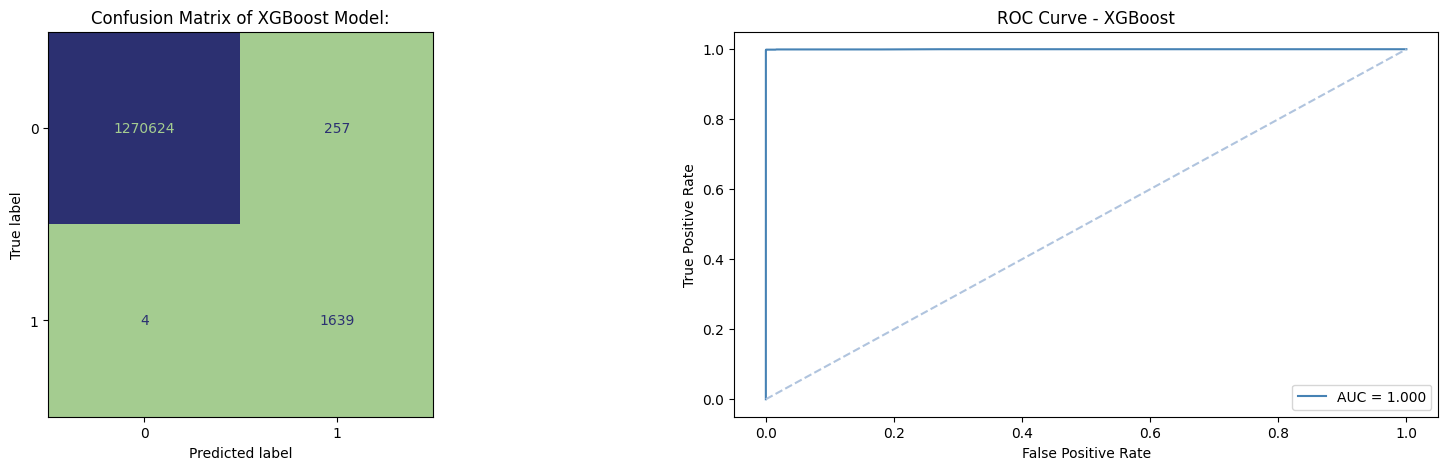

In [42]:
fig, ax = plt.subplots(1, 2, figsize=(20,5))
ax[0].set_title('Confusion Matrix of XGBoost Model:')
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, colorbar=False, values_format='', cmap='crest', ax=ax[0])
ax[0].grid(False)



fpr, tpr, thresholds = roc_curve(y_test, y_pred_score)
roc_auc = auc(fpr, tpr)                       
ax[1].set_title('ROC Curve - XGBoost')
ax[1].plot(fpr, tpr, label = 'AUC = %0.3f' % roc_auc, c='steelblue')
ax[1].plot([0,1],[0,1],'--', c='lightsteelblue')
ax[1].legend(loc='lower right')
ax[1].set_ylabel('True Positive Rate')
ax[1].set_xlabel('False Positive Rate')